In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
from glob import glob
from scipy.spatial import cKDTree
from astropy.table import hstack


In [ ]:
def get_image3_catalog(filedir, filter, galaxy, level='lv3'):
    cat_dir = filedir
    # cat_dir = dir + f"{galaxy}/{filter.upper()}/{level}"
    cat_filename = f"{galaxy}_nircam_{level}_{filter.lower()}_cat_align.ecsv"
    cat_name = cat_dir + "/" + cat_filename
    return cat_name


# Path to my directory and the folder that I want outputs to be saved to
root_dir = "/nexus/posix0/MIA-astro-env/eschinner/reho/"
jwst_dir = root_dir + "centres/data/v4p1_temp"

# ------------------------------------
# This is where we set our parameters!
gal = 'ngc2997'
inst = 'nircam'
level = 'lv3'
mosaic_ext = 'i2d_anchor.fits'
band1 = 'f150w'
band2 = 'f212n'
# ------------------------------------

# Load the catalog
filename1 = glob(f"/nexus/posix0/MIA-astro-env/eschinner/reho/centres/catalogs_using_v2p0/*{band1}*cat.fits")[0]
filename2 = glob(f"/nexus/posix0/MIA-astro-env/eschinner/reho/centres/catalogs_using_v2p0/*{band2}*cat.fits")[0]
my_catalog1 = Table.read(filename1)
my_catalog2 = Table.read(filename2)

# Turn this into a filename and a path
filename1 = gal + "_" + inst + "_lv3_" + band1 + "_" + mosaic_ext
filename2 = gal + "_" + inst + "_lv3_" + band2 + "_" + mosaic_ext
# path = jwst_dir + gal + "/" + band.upper() + "/" + level + "/"
path = jwst_dir# + filename

pjpipe_cat_name1 = get_image3_catalog(jwst_dir, band1, gal, level=level)
pjpipe_cat_name2 = get_image3_catalog(jwst_dir, band2, gal, level=level)
pjpipe_cat1 = Table.read(pjpipe_cat_name1)
pjpipe_cat2 = Table.read(pjpipe_cat_name2)


In [6]:
print(my_catalog1.colnames)
print(pjpipe_cat1.colnames)
cols_to_keep = ['id', 'xcenter', 'ycenter', 'xcentroid', 'ycentroid', 'aperture_sum_abmag', 'aper_total_abmag']
# Keep cols_to_keep assming they are in the catalog, otherwise keep all columns
my_catalog1 = my_catalog1[[col for col in cols_to_keep if col in my_catalog1.colnames]]
pjpipe_cat1 = pjpipe_cat1[[col for col in cols_to_keep if col in pjpipe_cat1.colnames]]
my_catalog2 = my_catalog2[[col for col in cols_to_keep if col in my_catalog2.colnames]]
pjpipe_cat2 = pjpipe_cat2[[col for col in cols_to_keep if col in pjpipe_cat2.colnames]]


def match(my_catalog, pjpipe_cat, npix=2, my_xcol='xcenter', my_ycol='ycenter', pj_xcol='xcentroid', pj_ycol='ycentroid', keys=['my', 'pjpipe']):
    # Build KD-tree from pjpipe_cat coordinates
    pjpipe_coords = np.array([pjpipe_cat[pj_xcol], pjpipe_cat[pj_ycol]]).T
    my_coords = np.array([my_catalog[my_xcol], my_catalog[my_ycol]]).T

    tree = cKDTree(pjpipe_coords)

    # Find matches within npix pixels (using Euclidean distance)
    pixel_scale = 1#0.031
    max_distance = pixel_scale * npix  # or e.g. 1.0 pixel if you want 1 pixel tolerance

    distances, indices = tree.query(my_coords, k=1, distance_upper_bound=max_distance)

    # Create mask for valid matches (finite distance = match found)
    match_mask = np.isfinite(distances)

    # Build matched catalog
    matched_my = my_catalog[match_mask]
    matched_pjpipe = pjpipe_cat[indices[match_mask]]

    # Optionally combine columns from both catalogs
    matched_cat = hstack([matched_my, matched_pjpipe], table_names=[keys[0], keys[1]])
    return matched_cat



['id', 'xcenter', 'ycenter', 'aperture_sum_abmag']
['xcentroid', 'ycentroid', 'aper_total_abmag']


['id_f150w', 'xcenter_f150w', 'ycenter_f150w', 'aperture_sum_abmag_f150w', 'xcentroid_f150w', 'ycentroid_f150w', 'aper_total_abmag_f150w', 'id_f212n', 'xcenter_f212n', 'ycenter_f212n', 'aperture_sum_abmag_f212n', 'xcentroid_f212n', 'ycentroid_f212n', 'aper_total_abmag_f212n']
5091


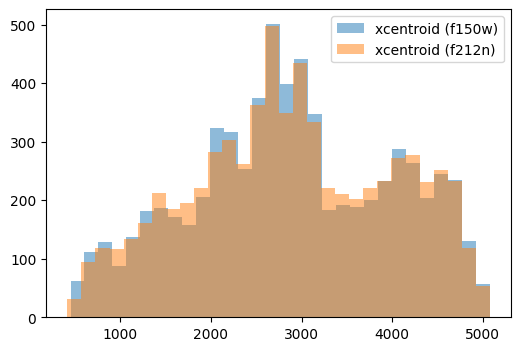

In [7]:
matched_cat_f150w = match(my_catalog1, pjpipe_cat1)
matched_cat_f212n = match(my_catalog2, pjpipe_cat2)

# Make a scatter plot of the f212n - f1w0w xcentroids against f212n - f150w ycentroids
plt.figure(figsize=(6, 4))
plt.hist(matched_cat_f150w['xcentroid'], bins=30, alpha=0.5, label='xcentroid (f150w)')
plt.hist(matched_cat_f212n['xcentroid'], bins=30, alpha=0.5, label='xcentroid (f212n)')
plt.legend()

# Need ti. do an extra match to get the same sources in both bands
final_matched_cat = match(matched_cat_f150w, 
                          matched_cat_f212n, 
                          my_xcol='xcentroid', 
                          my_ycol='ycentroid', 
                          pj_xcol='xcentroid', 
                          pj_ycol='ycentroid', 
                          keys=['f150w', 'f212n'])
print(final_matched_cat.colnames)
print(len(final_matched_cat))

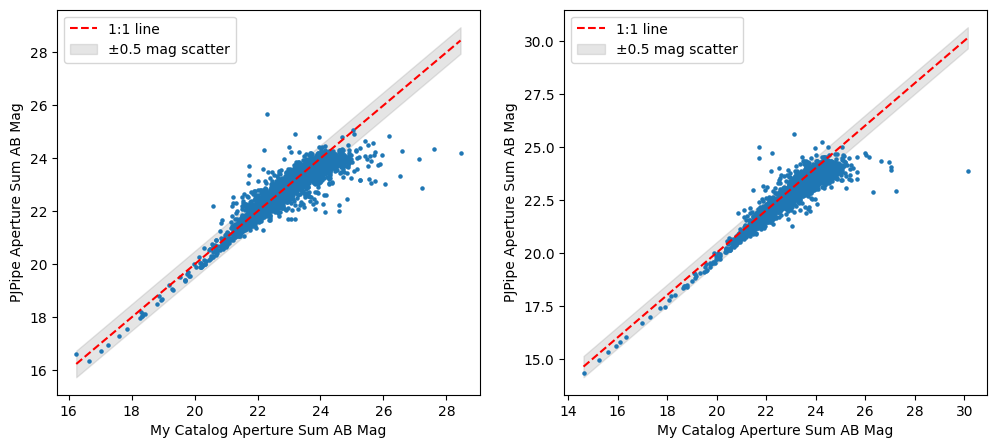

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(matched_cat_f150w['aperture_sum_abmag'], matched_cat_f150w['aper_total_abmag'], s=5)
# Plot 1:1 line for reference
min_mag = min(matched_cat_f150w['aperture_sum_abmag'].min(), matched_cat_f150w['aper_total_abmag'].min())
max_mag = max(matched_cat_f150w['aperture_sum_abmag'].max(), matched_cat_f150w['aper_total_abmag'].max())
ax[0].plot([min_mag, max_mag], [min_mag, max_mag], 'r--', label='1:1 line')
# Plot shaded region that corresponds to the error in scatter of the data points
ax[0].fill_between([min_mag, max_mag], [min_mag-0.5, max_mag-0.5], [min_mag+0.5, max_mag+0.5], color='gray', alpha=0.2, label='±0.5 mag scatter', zorder=-1)
ax[0].legend()
ax[0].set_ylabel('PJPipe Aperture Sum AB Mag')
ax[0].set_xlabel('My Catalog Aperture Sum AB Mag')
# Same for f212n
ax[1].scatter(matched_cat_f212n['aperture_sum_abmag'], matched_cat_f212n['aper_total_abmag'], s=5)
min_mag = min(matched_cat_f212n['aperture_sum_abmag'].min(), matched_cat_f212n['aper_total_abmag'].min())
max_mag = max(matched_cat_f212n['aperture_sum_abmag'].max(), matched_cat_f212n['aper_total_abmag'].max())
ax[1].plot([min_mag, max_mag], [min_mag, max_mag], 'r--', label='1:1 line')
ax[1].fill_between([min_mag , max_mag], [min_mag-0.5, max_mag-0.5], [min_mag+0.5, max_mag+0.5], color='gray', alpha=0.2, label='±0.5 mag scatter', zorder=-1)
ax[1].legend()
ax[1].set_ylabel('PJPipe Aperture Sum AB Mag')
ax[1].set_xlabel('My Catalog Aperture Sum AB Mag')
plt.show()

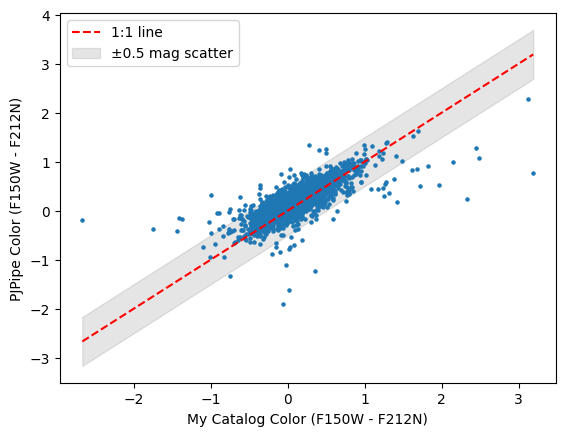

In [10]:
# colour
my_color = final_matched_cat['aperture_sum_abmag_f150w'] - final_matched_cat['aperture_sum_abmag_f212n']
pjpipe_color = final_matched_cat['aper_total_abmag_f150w'] - final_matched_cat['aper_total_abmag_f212n']
# Make the same plot as above but for the colour instead of the magnitude
fig, ax = plt.subplots()
ax.scatter(my_color, pjpipe_color, s=5)
# Plot 1:1 line for reference
min_color = min(my_color.min(), pjpipe_color.min())
max_color = max(my_color.max(), pjpipe_color.max())
ax.plot([min_color, max_color], [min_color, max_color], 'r--', label='1:1 line')
# Plot shaded region that corresponds to the error in scatter of the data points
ax.fill_between([min_color, max_color], [min_color-0.5, max_color-0.5], [min_color+0.5, max_color+0.5], color='gray', alpha=0.2, label='±0.5 mag scatter', zorder=-1)
ax.legend()
ax.set_ylabel('PJPipe Color (F150W - F212N)')
ax.set_xlabel('My Catalog Color (F150W - F212N)')
plt.show()